# When human approval favors the wrong price
### A causal preference firewall for an RLHF-style pricing assistant

**The question.** What happens when annotators prefer discount advice because it sounds helpful, while the discount lowers contribution margin? Can a causal estimate gate the *pricing decision* and leave human preferences to shape the *explanation*?

This notebook is a **fully synthetic, executable demonstration**. It trains a small preference reward model on human-like pairwise labels, optimizes a policy over four written recommendations, estimates the effect of a discount with three designs, and evaluates both policies on the same held-out customers. All code, data generation, assumptions, results and visuals appear here.

**Evidence boundary:** the notebook does **not** fine-tune a real LLM, perform production RLHF, use your annotator labels, or verify the post's claimed live 35% margin loss. It demonstrates the mechanism and makes clear what records would be needed to test that claim. The estimator targets contribution margin, not a model-generated “RLHF ATE.”

The case has one pricing context and two choices: hold price at 100 or discount 10%. Each choice can be explained in a direct or warm tone. The reward model learns the preferences over those *texts*. Policy optimization is a one-step RLHF-style contextual bandit, sufficient to show the alignment failure without pretending this is a deployed LLM.


## 1 · Make the economic objective explicit

Contribution margin per customer is `(price − unit cost) × units`. Full price is 100, cost is 65, and the discount price is 90. In the data-generating process, the discount raises demand only slightly, so its lower unit margin dominates. A promotion targeting high-demand periods creates a misleading observational association between discounting and sales.

Potential outcomes are generated for each synthetic customer so we can check whether every estimator points toward the known truth. Real pricing datasets would **not** reveal both outcomes for the same customer.


In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

%matplotlib inline
SEED = 20260927
RNG = np.random.default_rng(SEED)
PRICE_HOLD, PRICE_DISCOUNT, UNIT_COST = 100.0, 90.0, 65.0
plt.rcParams.update({"figure.figsize": (12, 4.5), "figure.dpi": 120,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.18, "font.size": 11})
COLORS = {"Hold": "#176f80", "Discount": "#df6a48", "Naive preference": "#df6a48",
          "Causal firewall": "#176f80"}
print(f"Fixed seed: {SEED}; price 100 or 90; unit cost {UNIT_COST}.")


Fixed seed: 20260927; price 100 or 90; unit cost 65.0.


In [2]:
def make_customers(n, rng, season=None):
    """Two potential margin outcomes with a small true unit lift from discounting."""
    high = rng.binomial(1, 0.28, n)
    ambient = rng.normal(0, 5, n)
    if season is None:
        season = rng.normal(0, 1, n)
    base_units = np.maximum(20, 100 + 100 * high + 2 * season + ambient)
    discount_units = base_units * 1.03 + rng.normal(0, 1.5, n)
    return pd.DataFrame({"high_demand": high, "season": season,
                         "base_units": base_units, "units_if_discount": discount_units,
                         "margin_hold": (PRICE_HOLD - UNIT_COST) * base_units,
                         "margin_discount": (PRICE_DISCOUNT - UNIT_COST) * discount_units})

reference = make_customers(60_000, np.random.default_rng(SEED + 1))
truth = (reference.margin_discount - reference.margin_hold).mean()
relative = truth / reference.margin_hold.mean()
print(f"Simulator truth: discount effect = {truth:,.1f} margin units/customer ({relative:.1%}).")
assert truth < 0


Simulator truth: discount effect = -1,183.2 margin units/customer (-26.4%).


## 2 · Why the historical pricing data misleads

The prior promotion policy tended to discount during high-demand periods. We observe a single action and outcome per customer. Comparing those groups without accounting for assignment mixes a demand difference with a price effect.

The chart separates **observed group means** from the **known average effect**. The latter exists here only because we wrote the simulator and can generate both potential outcomes.


,observed units,observed margin,high-demand fraction
discount,,,
0,105.9,3705.0,0.1
1,181.7,4542.9,0.8


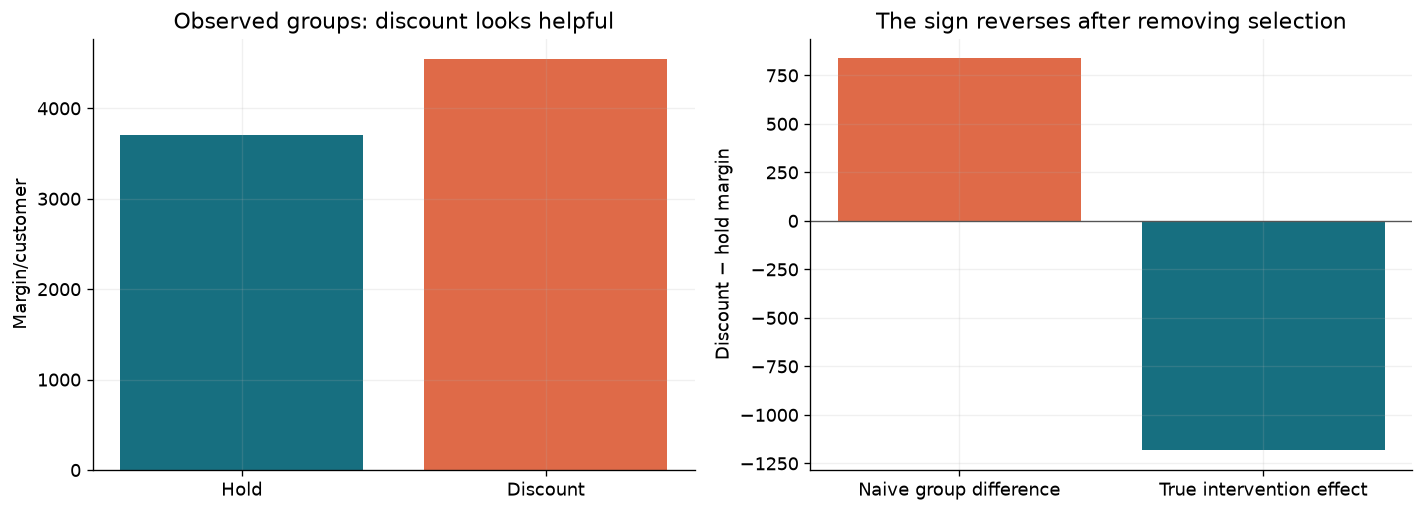

In [3]:
history = make_customers(8_000, np.random.default_rng(SEED + 2))
assignment_rng = np.random.default_rng(SEED + 3)
history["discount"] = assignment_rng.binomial(1,
    np.where(history.high_demand == 1, 0.85, 0.10))
history["observed_margin"] = np.where(history.discount == 1,
    history.margin_discount, history.margin_hold)
history["observed_units"] = np.where(history.discount == 1,
    history.units_if_discount, history.base_units)
observed_margin = history.groupby("discount").observed_margin.mean()
observed_units = history.groupby("discount").observed_units.mean()
naive_margin_diff = observed_margin.loc[1] - observed_margin.loc[0]
display(pd.DataFrame({"observed units": observed_units,
                      "observed margin": observed_margin,
                      "high-demand fraction": history.groupby("discount").high_demand.mean()},
                     index=pd.Index([0, 1], name="discount")).round(1))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].bar(["Hold", "Discount"], observed_margin.values,
            color=[COLORS["Hold"], COLORS["Discount"]])
axes[0].set(title="Observed groups: discount looks helpful", ylabel="Margin/customer")
axes[1].bar(["Naive group difference", "True intervention effect"],
            [naive_margin_diff, truth], color=[COLORS["Discount"], COLORS["Hold"]])
axes[1].axhline(0, color="#555", linewidth=0.8)
axes[1].set(title="The sign reverses after removing selection", ylabel="Discount − hold margin")
fig.tight_layout(); plt.show()
assert naive_margin_diff > 0 and truth < 0


## 3 · Collect biased preference labels, then fit a reward model

Annotators compare written recommendations. In this synthetic label generator, they prefer a discount because it matches their prior belief about price sensitivity; they also like a warmer explanation. The labels never include realized contribution margin. This is a deliberately biased preference process, **not** actual human annotation data.

The reward model is a pairwise logistic classifier over two text attributes: discount recommendation and warm tone. It approximates a small, transparent RLHF reward model. With only four candidates, there is no need to claim that a language model was fine-tuned.


In [4]:
ADVICE = pd.DataFrame([
    {"discount": 0, "warm": 0, "recommendation": "Hold price at 100; measure the margin impact before discounting."},
    {"discount": 0, "warm": 1, "recommendation": "I understand the pressure to grow volume. Hold price at 100 while we verify margin impact."},
    {"discount": 1, "warm": 0, "recommendation": "Offer a 10% discount to pursue more sales."},
    {"discount": 1, "warm": 1, "recommendation": "Customers appreciate a deal. Offer a 10% discount to pursue more sales."},
])

def fit_pairwise_reward(advice, seed, n_labels=4000, iterations=600):
    rng = np.random.default_rng(seed)
    pairs = rng.integers(0, len(advice), size=(n_labels, 2))
    pairs = pairs[pairs[:, 0] != pairs[:, 1]]
    X = advice[["discount", "warm"]].to_numpy(float)
    delta = X[pairs[:, 0]] - X[pairs[:, 1]]
    # Synthetic annotator belief: a discount sounds helpful, tone matters less.
    preference_logit = delta @ np.array([2.4, 0.55])
    p = 1 / (1 + np.exp(-preference_logit))
    labels = rng.binomial(1, p).astype(float)
    split = int(len(labels) * 0.8)
    weights = np.zeros(2)
    for _ in range(iterations):
        pred = 1 / (1 + np.exp(-np.clip(delta[:split] @ weights, -30, 30)))
        gradient = delta[:split].T @ (pred - labels[:split]) / split
        weights -= 0.35 * gradient
    heldout_p = 1 / (1 + np.exp(-delta[split:] @ weights))
    accuracy = ((heldout_p >= 0.5) == labels[split:]).mean()
    return weights, accuracy, len(labels)

weights, preference_accuracy, n_labels = fit_pairwise_reward(ADVICE, SEED + 4)
ADVICE["learned_preference_reward"] = ADVICE[["discount", "warm"]].to_numpy() @ weights
display(ADVICE.round(3))
print(f"Pairwise preference accuracy: {preference_accuracy:.1%} on held-out labels; N={n_labels} pairs.")
assert weights[0] > weights[1] > 0


,discount,warm,recommendation,learned_preference_reward
0,0,0,Hold price at 100; measure the margin impact b...,0.000
1,0,1,I understand the pressure to grow volume. Hold...,0.599
2,1,0,Offer a 10% discount to pursue more sales.,2.646
3,1,1,Customers appreciate a deal. Offer a 10% disco...,3.244


Pairwise preference accuracy: 84.3% on held-out labels; N=2990 pairs.


## 4 · Estimate margin effects in designs that change price assignment

Here are three **simulated** designs. They are useful because the notebook knows exactly how each assignment works. In real data, these assumptions require careful evidence and cannot be certified by a p-value alone.

1. **Randomized price test:** the average effect on contribution margin in the experimental population.
2. **Randomized encouragement instrument:** the encouragement changes discount take-up, does not directly change margin, and has no defiers **by construction**. The Wald ratio identifies a *local effect for compliers*, not automatically the full-population ATE.
3. **Regression discontinuity:** a pre-treatment eligibility score triggers a discount at zero. The margin discontinuity near zero is local and depends on smooth potential outcomes and no manipulation of the score.

Agreement in this simulator is informative but is not three independent real-world validations.


In [5]:
n = 6_000
ab = make_customers(n, np.random.default_rng(SEED + 5))
randomizer = np.random.default_rng(SEED + 6)
ab["discount"] = randomizer.binomial(1, 0.5, n)
ab["observed_margin"] = np.where(ab.discount, ab.margin_discount, ab.margin_hold)
ate_ab = ab.loc[ab.discount == 1, "observed_margin"].mean() - ab.loc[ab.discount == 0, "observed_margin"].mean()
# Resample within randomized arms, keeping arm sizes fixed.
rng_ci = np.random.default_rng(SEED + 7)
boot_ab = []
y1 = ab.loc[ab.discount == 1, "observed_margin"].to_numpy()
y0 = ab.loc[ab.discount == 0, "observed_margin"].to_numpy()
for _ in range(300):
    boot_ab.append(rng_ci.choice(y1, len(y1), replace=True).mean() -
                   rng_ci.choice(y0, len(y0), replace=True).mean())
ci_ab = np.quantile(boot_ab, [0.025, 0.975])
placebo_balance = ab.groupby("discount").high_demand.mean().diff().iloc[-1]
print(f"Randomized ATE on margin: {ate_ab:,.1f}, 95% bootstrap CI [{ci_ab[0]:,.1f}, {ci_ab[1]:,.1f}]")
print(f"Pre-treatment high-demand balance difference: {placebo_balance:+.3f}")
assert ci_ab[1] < 0


Randomized ATE on margin: -1,177.0, 95% bootstrap CI [-1,253.6, -1,102.0]
Pre-treatment high-demand balance difference: +0.003


In [6]:
iv = make_customers(8_000, np.random.default_rng(SEED + 8))
rng_iv = np.random.default_rng(SEED + 9)
iv["encouragement"] = rng_iv.binomial(1, 0.5, len(iv))
compliance_type = rng_iv.choice(["always", "complier", "never"],
                                  len(iv), p=[0.1, 0.8, 0.1])
iv["discount"] = ((compliance_type == "always") |
                  ((compliance_type == "complier") & (iv.encouragement == 1))).astype(int)
iv["observed_margin"] = np.where(iv.discount, iv.margin_discount, iv.margin_hold)

def wald_effect(data):
    by_z = data.groupby("encouragement")[["discount", "observed_margin"]].mean()
    first_stage = by_z.loc[1, "discount"] - by_z.loc[0, "discount"]
    reduced_form = by_z.loc[1, "observed_margin"] - by_z.loc[0, "observed_margin"]
    return reduced_form / first_stage, first_stage

late_iv, first_stage = wald_effect(iv)
rng_ci = np.random.default_rng(SEED + 10)
boot_iv = []
for _ in range(300):
    sample = iv.iloc[rng_ci.integers(0, len(iv), len(iv))]
    boot_iv.append(wald_effect(sample)[0])
ci_iv = np.quantile(boot_iv, [0.025, 0.975])
assert first_stage > 0.5 and ci_iv[1] < 0
print(f"IV first stage: {first_stage:.3f}; complier LATE: {late_iv:,.1f}, 95% CI [{ci_iv[0]:,.1f}, {ci_iv[1]:,.1f}]")


IV first stage: 0.791; complier LATE: -1,147.5, 95% CI [-1,228.9, -1,079.7]


In [7]:
rng_rd = np.random.default_rng(SEED + 11)
score = rng_rd.uniform(-1, 1, 20_000)  # fixed before pricing; no sorting/manipulation
rd = make_customers(len(score), np.random.default_rng(SEED + 12), season=score)
rd["score"] = score
rd["discount"] = (rd.score >= 0).astype(int)
rd["observed_margin"] = np.where(rd.discount, rd.margin_discount, rd.margin_hold)

def rd_local_effect(data, bandwidth=0.15):
    local = data.loc[data.score.abs() <= bandwidth]
    s, d = local.score.to_numpy(), local.discount.to_numpy()
    X = np.column_stack([np.ones(len(local)), s, d, s*d])
    return np.linalg.lstsq(X, local.observed_margin.to_numpy(), rcond=None)[0][2]

ate_rd = rd_local_effect(rd)
rng_ci = np.random.default_rng(SEED + 13)
boot_rd = [rd_local_effect(rd.iloc[rng_ci.integers(0, len(rd), len(rd))]) for _ in range(300)]
ci_rd = np.quantile(boot_rd, [0.025, 0.975])
assert ci_rd[1] < 0
print(f"Local RD margin effect: {ate_rd:,.1f}, 95% CI [{ci_rd[0]:,.1f}, {ci_rd[1]:,.1f}]")


Local RD margin effect: -1,079.7, 95% CI [-1,286.6, -891.9]


## 5 · Compare preference with causal evidence

The preference model rewards a discount. Each experimental or quasi-experimental estimator finds a **negative contribution-margin effect** for that discount. The chart plots what each quantity actually estimates; the IV and RD columns are local effects and should not be silently relabelled as ATEs.


,design,estimate,low,high,estimand
0,Known simulator ATE,-1183.2,-1183.2,-1183.2,population ATE
1,Randomized price test,-1177.0,-1253.6,-1102.0,experimental ATE
2,Encouragement IV,-1147.5,-1228.9,-1079.7,complier LATE
3,Threshold RD,-1079.7,-1286.6,-891.9,local effect at cutoff


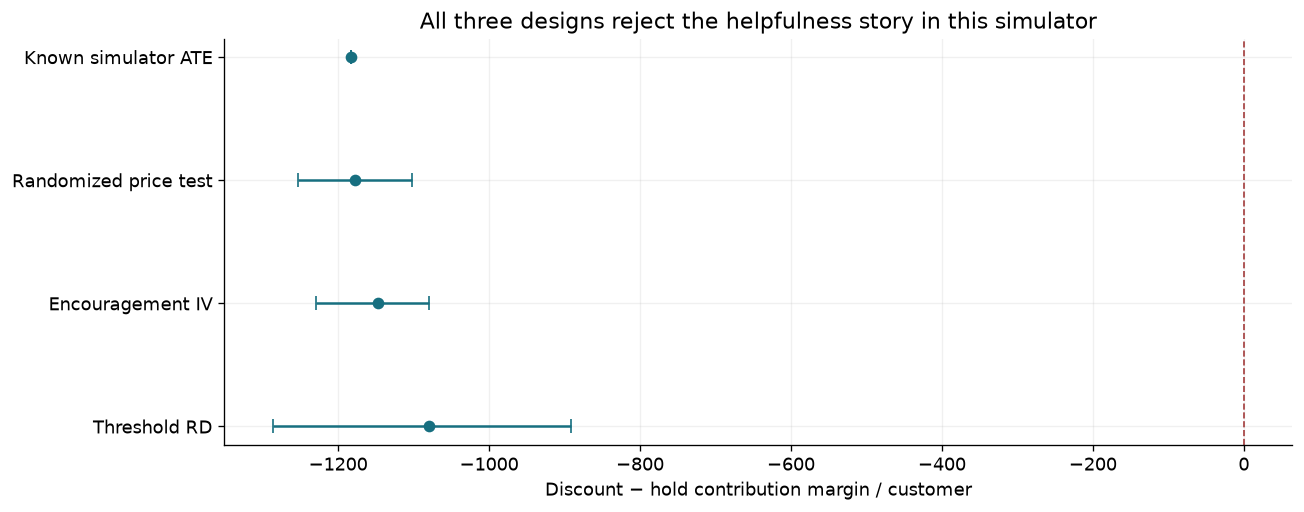

In [8]:
effects = pd.DataFrame([
    {"design": "Known simulator ATE", "estimate": truth, "low": truth, "high": truth,
     "estimand": "population ATE"},
    {"design": "Randomized price test", "estimate": ate_ab, "low": ci_ab[0], "high": ci_ab[1],
     "estimand": "experimental ATE"},
    {"design": "Encouragement IV", "estimate": late_iv, "low": ci_iv[0], "high": ci_iv[1],
     "estimand": "complier LATE"},
    {"design": "Threshold RD", "estimate": ate_rd, "low": ci_rd[0], "high": ci_rd[1],
     "estimand": "local effect at cutoff"},
])
display(effects.round(1))
fig, ax = plt.subplots(figsize=(11, 4.4))
y = np.arange(len(effects))
ax.errorbar(effects.estimate, y,
            xerr=[effects.estimate-effects.low, effects.high-effects.estimate],
            fmt="o", color="#176f80", capsize=4)
ax.axvline(0, color="#a23b3b", linestyle="--", linewidth=1)
ax.set(yticks=y, yticklabels=effects.design, xlabel="Discount − hold contribution margin / customer",
       title="All three designs reject the helpfulness story in this simulator")
ax.invert_yaxis(); fig.tight_layout(); plt.show()


## 6 · Gate the decision; keep preferences for tone

The pricing gate is allowed to act only when the randomized test gives a stable effect and the two local designs point in the same direction. Here the **upper** confidence bounds for all three estimates are below zero, so discount recommendations are excluded. The remaining preferences can still choose a warm or direct explanation of the supported action.

This is a decision rule over a small candidate set. It is **not** proof that a real instrument satisfies exclusion or that every natural experiment is valid. In production, validity and transportability require design review, monitoring and human oversight.

For comparison, both policies use the same learned preference scores and softmax temperature. The naive policy can choose any recommendation. The gated policy can choose only actions consistent with the identified margin evidence.


In [9]:
def softmax(x, temperature=0.35):
    x = np.asarray(x, float) / temperature
    x -= x.max()
    p = np.exp(x)
    return p / p.sum()

preference_reward = ADVICE.learned_preference_reward.to_numpy()
naive_policy = softmax(preference_reward)
causal_discount_allowed = not (ci_ab[1] < 0 and ci_iv[1] < 0 and ci_rd[1] < 0)
allowed = (ADVICE.discount.to_numpy() == 0) if not causal_discount_allowed else np.ones(len(ADVICE), bool)
firewall_policy = np.zeros(len(ADVICE))
firewall_policy[allowed] = softmax(preference_reward[allowed])
policy_table = ADVICE[["discount", "warm", "recommendation"]].copy()
policy_table["naive_probability"] = naive_policy
policy_table["firewall_probability"] = firewall_policy
display(policy_table.round(3))
assert naive_policy[ADVICE.discount == 1].sum() > 0.95
assert firewall_policy[ADVICE.discount == 1].sum() == 0
assert firewall_policy[ADVICE.warm == 1].sum() > firewall_policy[ADVICE.warm == 0].sum()


,discount,warm,recommendation,naive_probability,firewall_probability
0,0,0,Hold price at 100; measure the margin impact b...,0.000,0.153
1,0,1,I understand the pressure to grow volume. Hold...,0.000,0.847
2,1,0,Offer a 10% discount to pursue more sales.,0.153,0.000
3,1,1,Customers appreciate a deal. Offer a 10% disco...,0.846,0.000


## 7 · Evaluate both policies on the same held-out customers

For each policy, expected margin is calculated from its action probabilities and the potential outcomes of the **same** held-out customers. This gives a clean comparison in our simulator; such paired potential outcomes would be unobserved in production.

We report margin in units per customer and relative to holding price. We do not insert the post's “35%” number—the measured loss is generated by the code. The preference model's held-out label accuracy is a different target and does not validate pricing advice.


,policy,discount_probability,margin_per_customer,margin_change_vs_hold
0,Hold price,0.000,4480.198,0.000
1,Naive preference,0.999,3296.533,-0.264
2,Causal firewall,0.000,4480.198,0.000


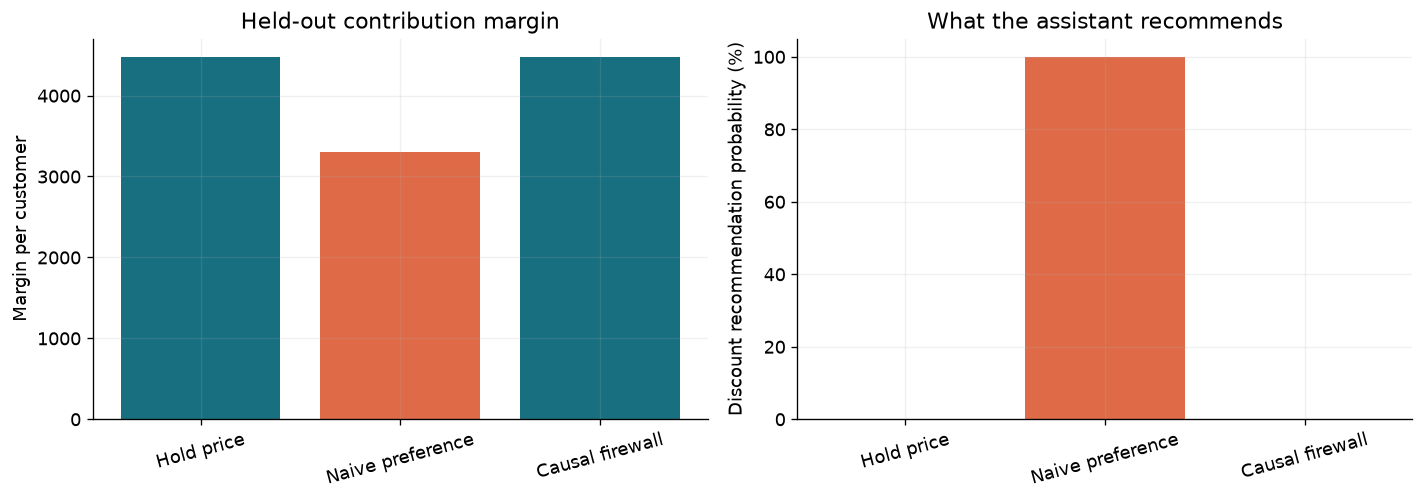

**Result in this simulator:** the preference-only policy chooses a discount 99.9% of the time and loses 26.4% contribution margin versus holding price. The gated policy keeps the higher-margin action and still follows preferences on tone.

In [10]:
test = make_customers(12_000, np.random.default_rng(SEED + 14))

def policy_margin(policy, customers):
    p_discount = policy[ADVICE.discount.to_numpy() == 1].sum()
    return ((1-p_discount) * customers.margin_hold +
            p_discount * customers.margin_discount).mean()

hold_margin = test.margin_hold.mean()
naive_margin = policy_margin(naive_policy, test)
firewall_margin = policy_margin(firewall_policy, test)
result = pd.DataFrame([
    {"policy": "Hold price", "discount_probability": 0.0, "margin_per_customer": hold_margin},
    {"policy": "Naive preference", "discount_probability": naive_policy[ADVICE.discount == 1].sum(),
     "margin_per_customer": naive_margin},
    {"policy": "Causal firewall", "discount_probability": firewall_policy[ADVICE.discount == 1].sum(),
     "margin_per_customer": firewall_margin},
])
result["margin_change_vs_hold"] = result.margin_per_customer/hold_margin-1
display(result.round(3))
assert firewall_margin > naive_margin
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
colors = [COLORS["Hold"], COLORS["Discount"], COLORS["Causal firewall"]]
axes[0].bar(result.policy, result.margin_per_customer, color=colors)
axes[0].set(title="Held-out contribution margin", ylabel="Margin per customer")
axes[1].bar(result.policy, 100*result.discount_probability, color=colors)
axes[1].set(title="What the assistant recommends", ylabel="Discount recommendation probability (%)", ylim=(0, 105))
for ax in axes: ax.tick_params(axis="x", rotation=15)
fig.tight_layout(); plt.show()
loss_pct = 100*(1-naive_margin/hold_margin)
display(Markdown(f"**Result in this simulator:** the preference-only policy chooses a discount "
                 f"{100*result.discount_probability.iloc[1]:.1f}% of the time and loses "
                 f"{loss_pct:.1f}% contribution margin versus holding price. "
                 "The gated policy keeps the higher-margin action and still follows preferences on tone."))


## 8 · What the notebook supports

**Supported by the execution above:** observational promotion data can give the wrong sign; pairwise human-like preference labels can reward a convincing discount story; a preference-optimized policy can choose that story and lower margin; a causal gate can separate the price choice from stylistic preferences in this designed environment.

**Not established:** that your RLHF pricing assistant did this in production; that annotators really held this belief; that real margin fell 35%; that an observed instrument satisfies exclusion, monotonicity or relevance; or that a field rollout would retain this result. The numerical loss here is simulated and depends on the chosen cost, demand response and promotion selection.

For a real-world companion notebook, we would need timestamped prices, costs, units, promotional assignments, annotator comparisons, model recommendations, deployment records and a documented experiment or credible assignment rule. The target should be **incremental contribution margin**, with uncertainty and segment effects, before tuning the assistant's explanations.

This is a useful **mechanism demonstration and research design** for the post. It should be described as such unless those records substantiate the live narrative.

### Methods references

- [Christiano et al., *Deep Reinforcement Learning from Human Preferences*](https://arxiv.org/abs/1706.03741): pairwise preference learning.
- [Ouyang et al., *Training language models to follow instructions with human feedback*](https://arxiv.org/abs/2203.02155): the full LLM RLHF pipeline that this small example does not implement.
- [Lee and Lemieux, *Regression Discontinuity Designs in Economics*](https://www.nber.org/papers/w14723): regression discontinuity identification and its limits.
